# STAC — live cloud read (Microsoft Planetary Computer, signed)

[Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/) hosts
its assets in Azure Blob Storage behind short-lived **SAS tokens**. pyramids'
`PlanetaryComputerSigner` mints those tokens with the standard library only (no
Azure SDK), grafts them onto each asset href, and installs the matching GDAL
environment around every read. Public collections need **no subscription key**.

> **Network required.** This notebook hits a live endpoint and is *excluded*
> from the CI notebook suite. Run it locally with `pip install
> 'pyramids-gis[stac]'`.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer

from pyramids.stac import (
    PlanetaryComputerSigner,
    load_asset,
    open_client,
    read_extension_metadata,
)

signer = PlanetaryComputerSigner()

2026-05-25 18:55:01 | INFO | pyramids.base.config | Logging is configured.


## 1. Open a signed client and search

`open_client(..., signer=signer)` wires the signer's `sign_request` (search) and
`sign_item` (returned-href rewrite) hooks into the `pystac_client`. The PC STAC
API uses the same `sentinel-2-l2a` collection, but its band assets are keyed
`B02`, `B03`, `B04`, … (raw band IDs) rather than `red` / `green` / `blue`.

In [2]:
client = open_client("https://planetarycomputer.microsoft.com/api/stac/v1", signer=signer)

result = client.search(
    collections=["sentinel-2-l2a"],
    bbox=(11.10, 46.05, 11.20, 46.12),
    datetime="2023-07-01/2023-09-30",
    query={"eo:cloud_cover": {"lt": 5}},
    max_items=3,
)
items = list(result.items())
item = items[0]

[(it.id, round(it.properties["eo:cloud_cover"], 2)) for it in items]

[('S2B_MSIL2A_20230925T100649_R022_T32TPS_20241026T081605', 0.01),
 ('S2B_MSIL2A_20230925T100649_R022_T32TPS_20230925T151656', 0.01),
 ('S2A_MSIL2A_20230910T100601_R022_T32TPS_20230910T182210', 0.16)]

## 2. Metadata without opening the file

In [3]:
meta = read_extension_metadata(item, "B04")
{k: meta[k] for k in ("crs", "shape", "band_names")}

{'crs': 'EPSG:32632', 'shape': [10980, 10980], 'band_names': ['B04']}

## 3. A signed, windowed read

Pass the signer to `load_asset` as well: it re-signs the href (a no-op if the
client already signed it) and installs the GDAL credentials for the read. The
`/vsicurl/` request fetches only the AOI window.

In [4]:
def utm_window(ds, lon, lat, half_m=1000):
    x, y = Transformer.from_crs(4326, ds.epsg, always_xy=True).transform(lon, lat)
    return (x - half_m, y - half_m, x + half_m, y + half_m)


CENTER = (11.15, 46.08)  # lon, lat

red = load_asset(item, "B04", signer=signer)
arr = red.read_array(bbox=utm_window(red, *CENTER, half_m=1000), epsg=red.epsg)

print("epsg:", red.epsg, "| window:", arr.shape)
print("min / mean / max:", int(np.nanmin(arr)), round(float(np.nanmean(arr)), 1), int(np.nanmax(arr)))

epsg: 32632 | window: (200, 200)
min / mean / max: 999 1497.5 10328


## 4. A true-colour thumbnail (B04 / B03 / B02)

composite shape: (300, 300, 3)


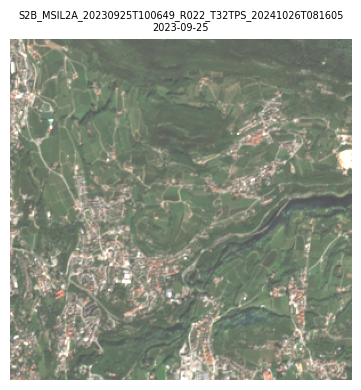

In [5]:
channels = {}
for name in ("B04", "B03", "B02"):
    band = load_asset(item, name, signer=signer)
    channels[name] = band.read_array(bbox=utm_window(band, *CENTER, half_m=1500), epsg=band.epsg)

rgb = np.dstack([channels["B04"], channels["B03"], channels["B02"]]).astype("float32")
rgb = np.clip(rgb / 3000.0, 0, 1)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(rgb)
ax.set_title(f"{item.id}\n{item.properties['datetime'][:10]}", fontsize=7)
ax.axis("off")
fig.tight_layout()
print("composite shape:", rgb.shape)

## Recap

- `PlanetaryComputerSigner` mints Azure SAS tokens with the standard library
  only — no Azure SDK, no subscription key for public collections.
- Wire it into `open_client(..., signer=...)` for search and into
  `load_asset(item, key, signer=...)` for the read; the same signer also feeds
  `DatasetCollection.from_stac(..., signer=...)` and
  `build_vrt_from_stac(..., signer=...)`.
- Everything else — windowed reads, RGB composites, cubes — works exactly as in
  the [Earth Search notebook](stac-cloud-earth-search.ipynb).

See the [Signers reference](../../reference/stac/signers.md) for the other auth
boundaries (AWS Requester-Pays, EDL bearer, CDSE).